In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from math import ceil

Sensor IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Number of sensors: 10


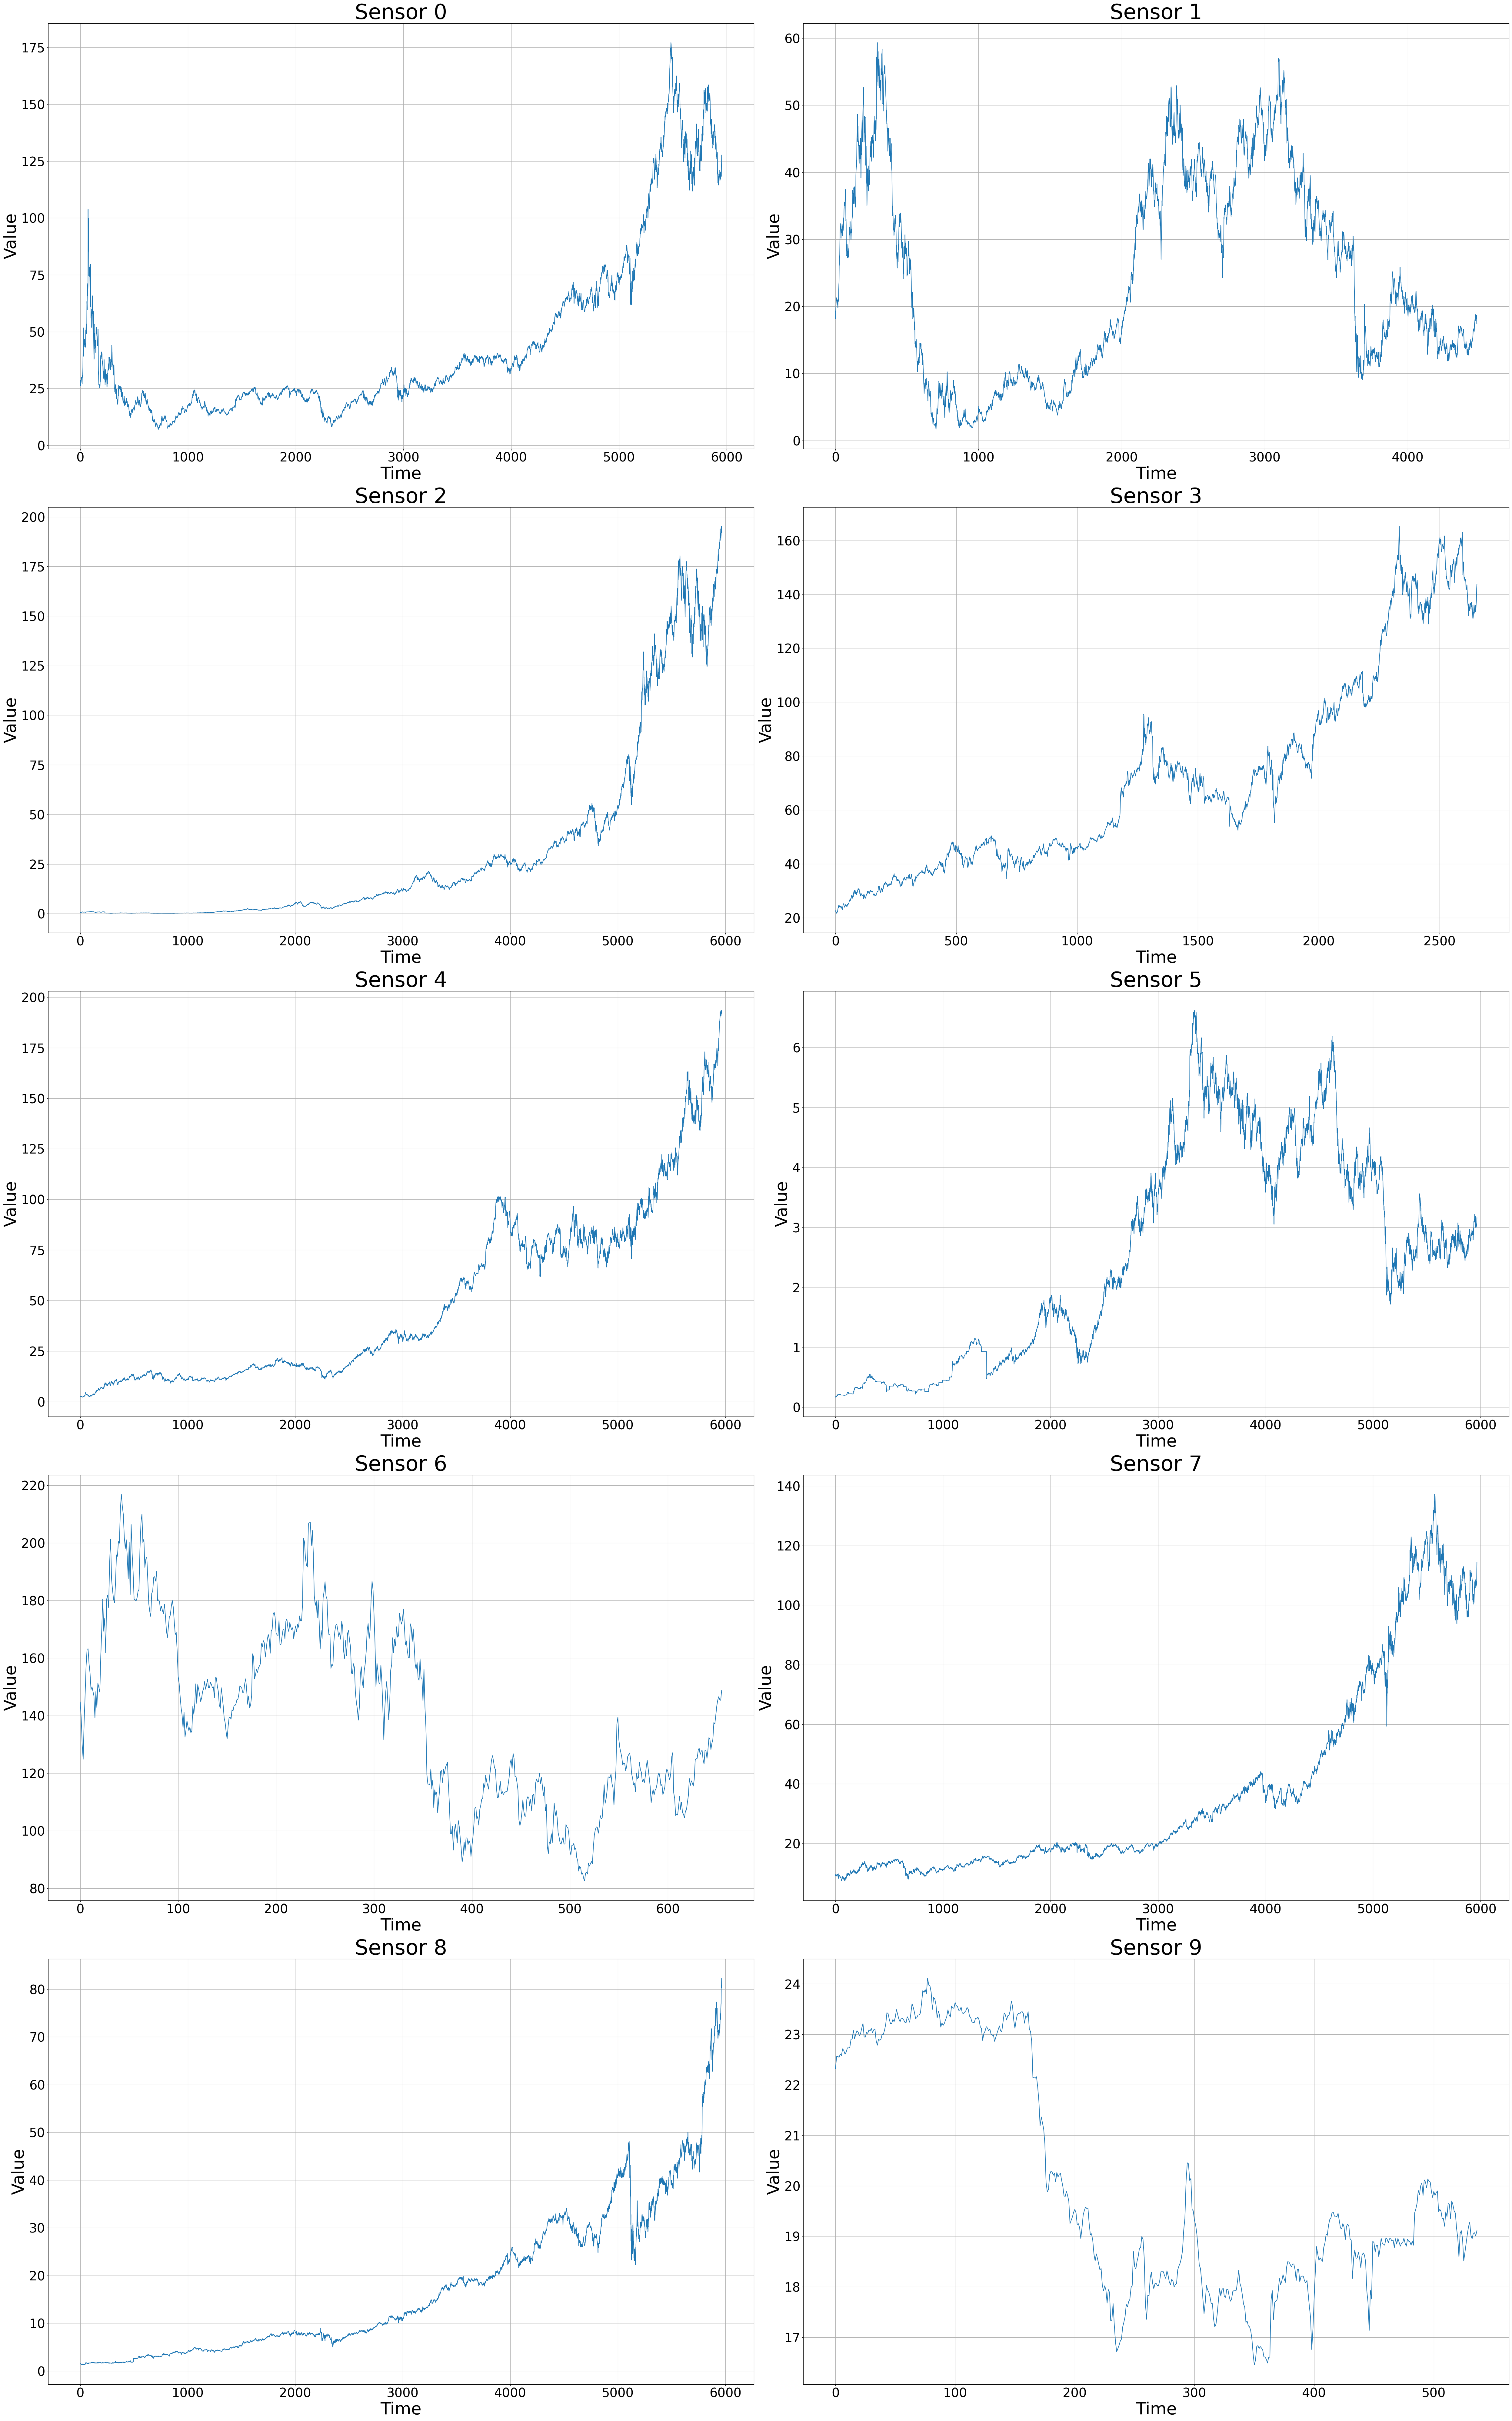

In [23]:


data = pd.read_csv('data.csv', sep=' ')

data = data.astype({'#Time': 'float64', 'SensorID': 'int', 'Value': 'float64'})

def plot_sensors_data(data):
    
    plt.rcParams.update({'xtick.labelsize': 30, 'ytick.labelsize': 30, 'axes.labelsize': 40, 'axes.titlesize': 50})
    
    # The number of the sensors
    sensors_num = len(data['SensorID'].unique())
    
    # The sensor IDs
    sensors_ids = sorted([int(id) for id in data['SensorID'].unique()])
    print("Sensor IDs:", sensors_ids)
    print(f"Number of sensors: {sensors_num}")
    
    # Define dimensions for plot
    f, axs = plt.subplots(ceil(sensors_num/2), 2, figsize=(50, 80))
    axs = axs.flatten()
    
    # Loop through sensor IDs
    for index, sensor_id in enumerate(sensors_ids):
        # Filter the specific sensor's data
        sensor_df = data[data['SensorID'] == sensor_id].copy()
        
        # Drop null values
        sensor_df = sensor_df.dropna(subset=['Value'])
        
        # Reset time to start from 0 for each sensor
        if not sensor_df.empty:
            min_time = sensor_df['#Time'].min()
            sensor_df['#Time'] = sensor_df['#Time'] - min_time
        
        axs[index].plot(sensor_df['#Time'], sensor_df['Value'])
        axs[index].set_title(f'Sensor {sensor_id}')
        axs[index].set_xlabel('Time')
        axs[index].set_ylabel('Value')
        axs[index].grid(True)
    
    plt.tight_layout()
    plt.savefig('sensor_plots.png')
    plt.show()

plot_sensors_data(data)


In [24]:
def create_dataset(data, time_step=5, future_step=1):
    X, Y = [], []
    for i in range(len(data) - time_step - future_step):
        X.append(data[i:(i + time_step), 0])
        Y.append(np.mean(data[i + time_step:i + time_step + future_step, 0]))
    return np.array(X), np.array(Y)

In [25]:
#Create empty lists to store data for each sensor
#Store scalers to inverse transform later if needed
X_trains = []
X_tests = []
Y_trains = []
Y_tests = []
scalers = []  
processed_sensors = []  # Keep track of which sensors were successfully processed

# Get unique sensor IDs
sensors_ids = sorted(list(data['SensorID'].unique()))

# Process each sensor separately
for sensor_id in sensors_ids:
    # Filter data for this specific sensor
    sensor_data = data[data['SensorID'] == sensor_id].copy()
    
    # Drop rows with null values in 'Value' column
    sensor_data = sensor_data.dropna(subset=['Value'])
    
    # Reset time to start from 0 for this sensor
    if not sensor_data.empty:
        min_time = sensor_data['#Time'].min()
        sensor_data['#Time'] = sensor_data['#Time'] - min_time
    
    # Check if we have enough data after removing nulls
    if len(sensor_data) <= 15:  
        print(f"Sensor {sensor_id} has insufficient data points after removing nulls. Skipping.")
        X_trains.append(None)
        X_tests.append(None)
        Y_trains.append(None)
        Y_tests.append(None)
        scalers.append(None)
        continue
    
    # Scale the data for this sensor
    scaler = MinMaxScaler(feature_range=(0, 1))
    sensor_data_scaled = scaler.fit_transform(sensor_data[['Value']])
    scalers.append(scaler)  # Save the scaler
    
    # Create dataset for this sensor
    time_step = 5
    X, Y = create_dataset(sensor_data_scaled, time_step, future_step=1)
    
    # Skip sensors with insufficient data
    if len(X) == 0:
        print(f"Sensor {sensor_id} has insufficient data points for time series creation. Skipping.")
        X_trains.append(None)
        X_tests.append(None)
        Y_trains.append(None)
        Y_tests.append(None)
        continue
    
    # Reshape for LSTM input
    X = X.reshape(X.shape[0], X.shape[1], 1)
    
    # Split into train and test sets
    split = int(0.5 * len(X))
    X_train, X_test = X[:split], X[split:]
    Y_train, Y_test = Y[:split], Y[split:]
    
    # Store the datasets
    X_trains.append(X_train)
    X_tests.append(X_test)
    Y_trains.append(Y_train)
    Y_tests.append(Y_test)
    processed_sensors.append(sensor_id)
    
    # Print information for this sensor
    print(f"\nSensor {sensor_id}:")
    #print(f"Original data points: {len(data[data['SensorID'] == sensor_id])}")
    #print(f"Data points after removing nulls: {len(sensor_data)}")
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"Y_train shape: {Y_train.shape}")
    print(f"Y_test shape: {Y_test.shape}")



Sensor 0:
X_train shape: (2974, 5, 1)
X_test shape: (2975, 5, 1)
Y_train shape: (2974,)
Y_test shape: (2975,)

Sensor 1:
X_train shape: (2239, 5, 1)
X_test shape: (2239, 5, 1)
Y_train shape: (2239,)
Y_test shape: (2239,)

Sensor 2:
X_train shape: (2980, 5, 1)
X_test shape: (2981, 5, 1)
Y_train shape: (2980,)
Y_test shape: (2981,)

Sensor 3:
X_train shape: (1325, 5, 1)
X_test shape: (1325, 5, 1)
Y_train shape: (1325,)
Y_test shape: (1325,)

Sensor 4:
X_train shape: (2980, 5, 1)
X_test shape: (2981, 5, 1)
Y_train shape: (2980,)
Y_test shape: (2981,)

Sensor 5:
X_train shape: (2980, 5, 1)
X_test shape: (2981, 5, 1)
Y_train shape: (2980,)
Y_test shape: (2981,)

Sensor 6:
X_train shape: (325, 5, 1)
X_test shape: (325, 5, 1)
Y_train shape: (325,)
Y_test shape: (325,)

Sensor 7:
X_train shape: (2980, 5, 1)
X_test shape: (2981, 5, 1)
Y_train shape: (2980,)
Y_test shape: (2981,)

Sensor 8:
X_train shape: (2980, 5, 1)
X_test shape: (2981, 5, 1)
Y_train shape: (2980,)
Y_test shape: (2981,)

Sens

In [26]:

# Lists to store models, histories, predictions, and actual values for each sensor
models = []
histories = []
test_predictions = []
Y_test_originals = []

# Process each sensor separately
for sensor_id in range(len(sensors_ids)):
    print(f"\n--- Processing Sensor {sensors_ids[sensor_id]} ---")
    
    # Skip sensors with insufficient data
    if X_trains[sensor_id] is None:
        print(f"Sensor {sensors_ids[sensor_id]} was skipped due to insufficient data.")
        models.append(None)
        histories.append(None)
        test_predictions.append(None)
        Y_test_originals.append(None)
        continue
    
    # Create a new model for this sensor
    model = Sequential([
        LSTM(50, activation='tanh', return_sequences=True, input_shape=(time_step, 1)),
        Dropout(0.2),
        LSTM(25, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    # Set up early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    
    # Train the model on this sensor's data with early stopping
    print(f"Training model for Sensor {sensors_ids[sensor_id]}...")
    
    # Split training data to create a validation set
    train_size = int(0.9 * len(X_trains[sensor_id]))
    X_train_final = X_trains[sensor_id][:train_size]
    Y_train_final = Y_trains[sensor_id][:train_size]
    X_val = X_trains[sensor_id][train_size:]
    Y_val = Y_trains[sensor_id][train_size:]
    
    # Train with validation data and early stopping
    history = model.fit(
        X_train_final, Y_train_final,
        batch_size=16,
        epochs=50,
        validation_data=(X_val, Y_val),
        callbacks=[early_stop],
        verbose=1
    )
    
    # Store the trained model and history
    models.append(model)
    histories.append(history)
    
    # Make predictions on test data
    test_predict = model.predict(X_tests[sensor_id])
    
    # Inverse transform predictions and actual values
    test_predict_original = scalers[sensor_id].inverse_transform(test_predict.reshape(-1, 1))
    Y_test_original = scalers[sensor_id].inverse_transform(Y_tests[sensor_id].reshape(-1, 1))
    
    # Store predictions and actual values
    test_predictions.append(test_predict_original)
    Y_test_originals.append(Y_test_original)
    
    
    # Calculate the error (difference between actual and predicted values)
    results = pd.DataFrame({
        'Actual': Y_test_original.flatten(),
        'Predicted': test_predict_original.flatten()
    })

    # Add error column
    results['Error'] = results['Actual'] - results['Predicted']

    # Save results to CSV with error column
    filename = f"predictions_sensor_{sensors_ids[sensor_id]}.csv"
    results.to_csv(filename, index=False)
    print(f"Predictions for Sensor {sensors_ids[sensor_id]} saved to '{filename}'")

    # Create error analysis plots
    plt.figure(figsize=(12, 6), dpi=100)

    # Scatter plot of Actual vs Predicted
    plt.subplot(1, 2, 1)
    plt.scatter(results['Actual'], results['Predicted'], alpha=0.5, color='#4472C4')
    plt.plot([results['Actual'].min(), results['Actual'].max()], 
            [results['Actual'].min(), results['Actual'].max()], 
            'r--', linewidth=2)
    plt.xlabel('Actual Values', fontsize=12, fontweight='bold')
    plt.ylabel('Predicted Values', fontsize=12, fontweight='bold')
    plt.title('Actual vs Predicted', fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Error distribution histogram
    plt.subplot(1, 2, 2)
    plt.hist(results['Error'], bins=30, color='#4472C4', alpha=0.8, edgecolor='black')
    plt.xlabel('Prediction Error', fontsize=12, fontweight='bold')
    plt.ylabel('Frequency', fontsize=12, fontweight='bold')
    plt.title('Error Distribution', fontsize=14, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    plt.tight_layout()
    plot_filename = f"error_analysis_sensor_{sensors_ids[sensor_id]}.png"
    plt.savefig(plot_filename, bbox_inches='tight')
    plt.close()

    print(f"Error analysis plot saved to '{plot_filename}'")





--- Processing Sensor 0 ---
Training model for Sensor 0...
Epoch 1/50


c:\Users\Mojta\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


168/168 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0017 - val_loss: 4.6246e-05
Epoch 2/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 3.3720e-04 - val_loss: 3.5609e-05
Epoch 3/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 2.1694e-04 - val_loss: 3.5928e-05
Epoch 4/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.9842e-04 - val_loss: 4.9356e-05
Epoch 5/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 2.2703e-04 - val_loss: 4.0384e-05
Epoch 6/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.8860e-04 - val_loss: 1.8406e-04
Epoch 7/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 1.7539e-04 - val_loss: 3.2284e-05
Epoch 8/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 2.8442e-04 - val_loss: 3.0535e-05
Epoch 9/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 2.2047e-04 - val_loss: 4.0672e-05
Epoch 10/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 1.9076e-04 - val_loss: 4.1856e-05
Epoch 11/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 1.

c:\Users\Mojta\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0213 - val_loss: 0.0015
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0020 - val_loss: 0.0028
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0020 - val_loss: 4.6504e-04
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0016 - val_loss: 0.0011
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0018 - val_loss: 6.2440e-04
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0012 - val_loss: 3.8519e-04
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0013 - val_loss: 3.8272e-04
Epoch 8/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0017 - val_loss: 6.6667e-04
Epoch 9/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0012 - val_loss: 6.3722e-04
Epoch 10/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0013 - val_loss: 6.2468e-04
Epoch 11/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0014 - val_loss: 3.9081e-04
Epoch 12/50
126/126 

...

168/168 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 5.6356e-04 - val_loss: 6.7016e-06
Epoch 2/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 2.3273e-05 - val_loss: 4.7826e-06
Epoch 3/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 2.2930e-05 - val_loss: 6.5071e-06
Epoch 4/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 1.9417e-05 - val_loss: 9.6232e-06
Epoch 5/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.9903e-05 - val_loss: 6.4408e-06
Epoch 6/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 2.2818e-05 - val_loss: 7.9021e-06
Epoch 7/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 1.9245e-05 - val_loss: 7.5188e-06
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Predictions for Sensor 7 saved to 'predictions_sensor_7.csv'
Error analysis plot saved to 'error_analysis_sensor_7.png'

--- Processing Sensor 8 ---
Training model for Sensor 8...
Epoch 1/50


c:\Users\Mojta\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


168/168 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 4.8497e-04 - val_loss: 5.1235e-06
Epoch 2/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 2.0601e-05 - val_loss: 4.9065e-06
Epoch 3/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 1.8475e-05 - val_loss: 9.0036e-06
Epoch 4/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.6875e-05 - val_loss: 5.4068e-06
Epoch 5/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 1.6520e-05 - val_loss: 7.3022e-06
Epoch 6/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 1.6004e-05 - val_loss: 5.2222e-06
Epoch 7/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1.6720e-05 - val_loss: 1.9379e-05
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Predictions for Sensor 8 saved to 'predictions_sensor_8.csv'
Error analysis plot saved to 'error_analysis_sensor_8.png'

--- Processing Sensor 9 ---
Training model for Sensor 9...
Epoch 1/50


c:\Users\Mojta\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.4829 - val_loss: 0.0088
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0458 - val_loss: 0.0612
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0329 - val_loss: 0.0264
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0221 - val_loss: 0.0345
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0209 - val_loss: 0.0222
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0188 - val_loss: 0.0132
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
Predictions for Sensor 9 saved to 'predictions_sensor_9.csv'
Error analysis plot saved to 'error_analysis_sensor_9.png'



Metrics for Sensor 0:
Mean Absolute Error (MAE): 3.4968
Mean Squared Error (MSE): 27.7062
Root Mean Squared Error (RMSE): 5.2637
R² Score: 0.9835
Plot for Sensor 0 saved as 'sensor_0_results.png'


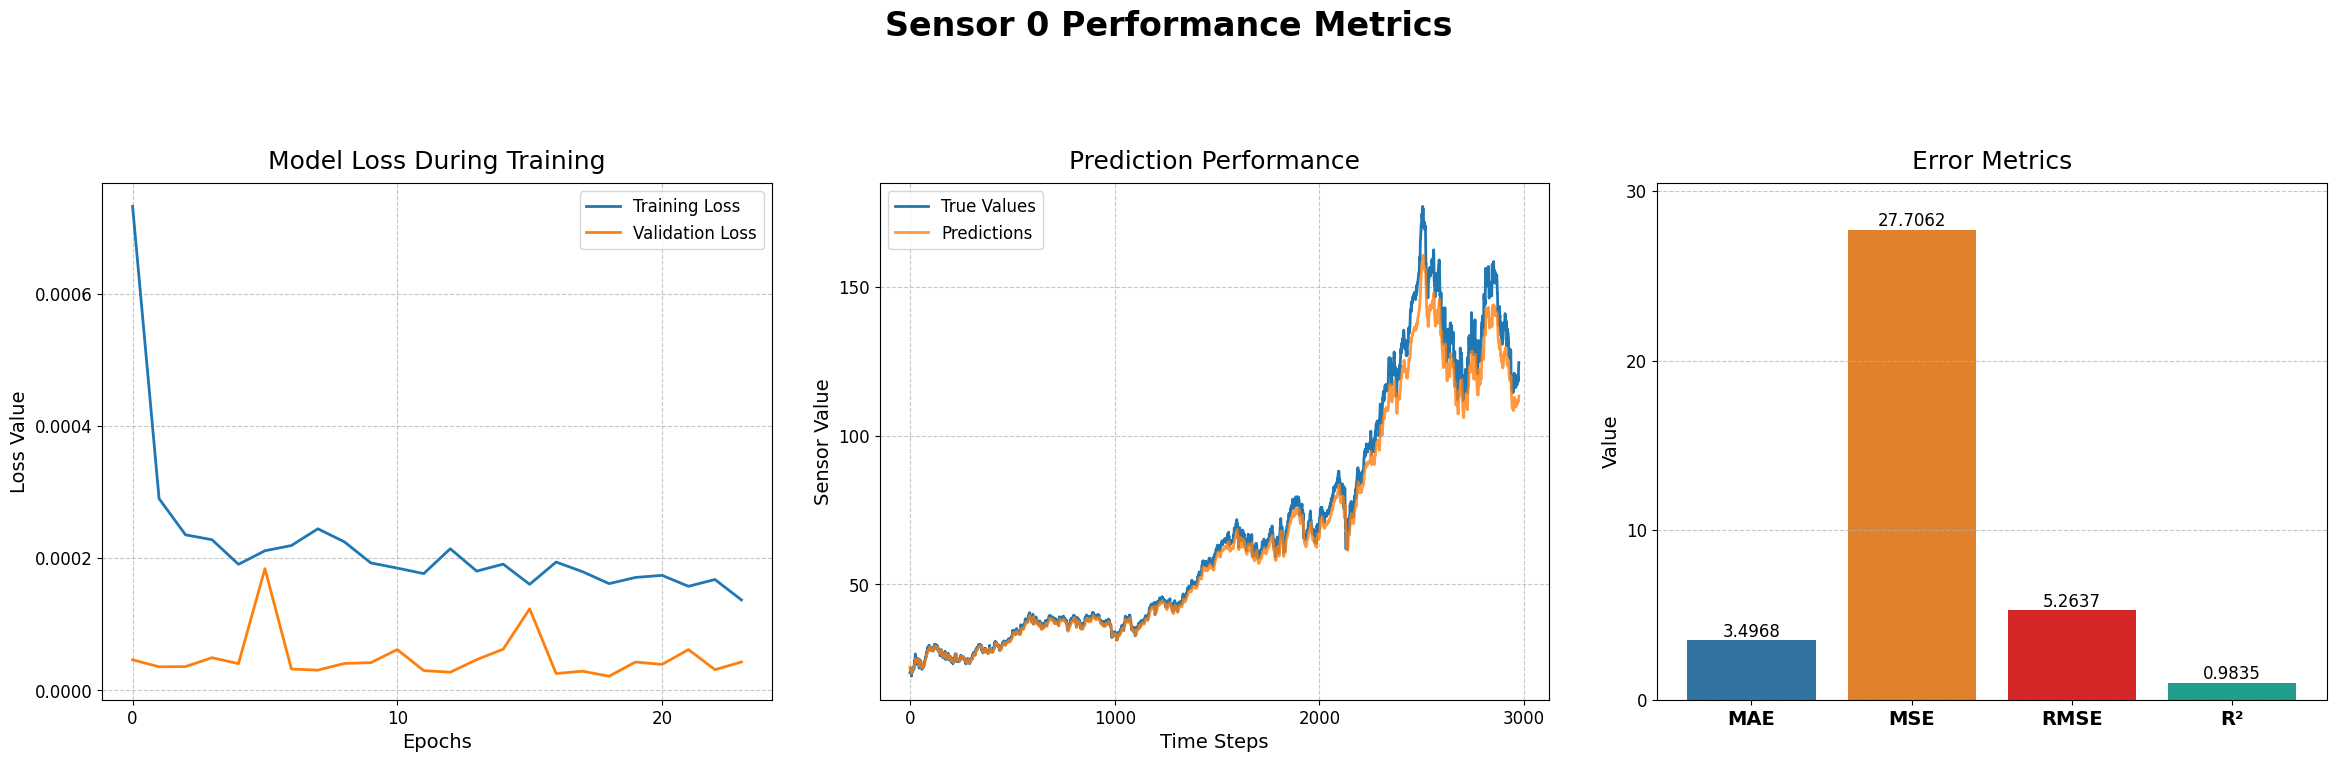


Metrics for Sensor 1:
Mean Absolute Error (MAE): 1.0520
Mean Squared Error (MSE): 1.9685
Root Mean Squared Error (RMSE): 1.4030
R² Score: 0.9879
Plot for Sensor 1 saved as 'sensor_1_results.png'


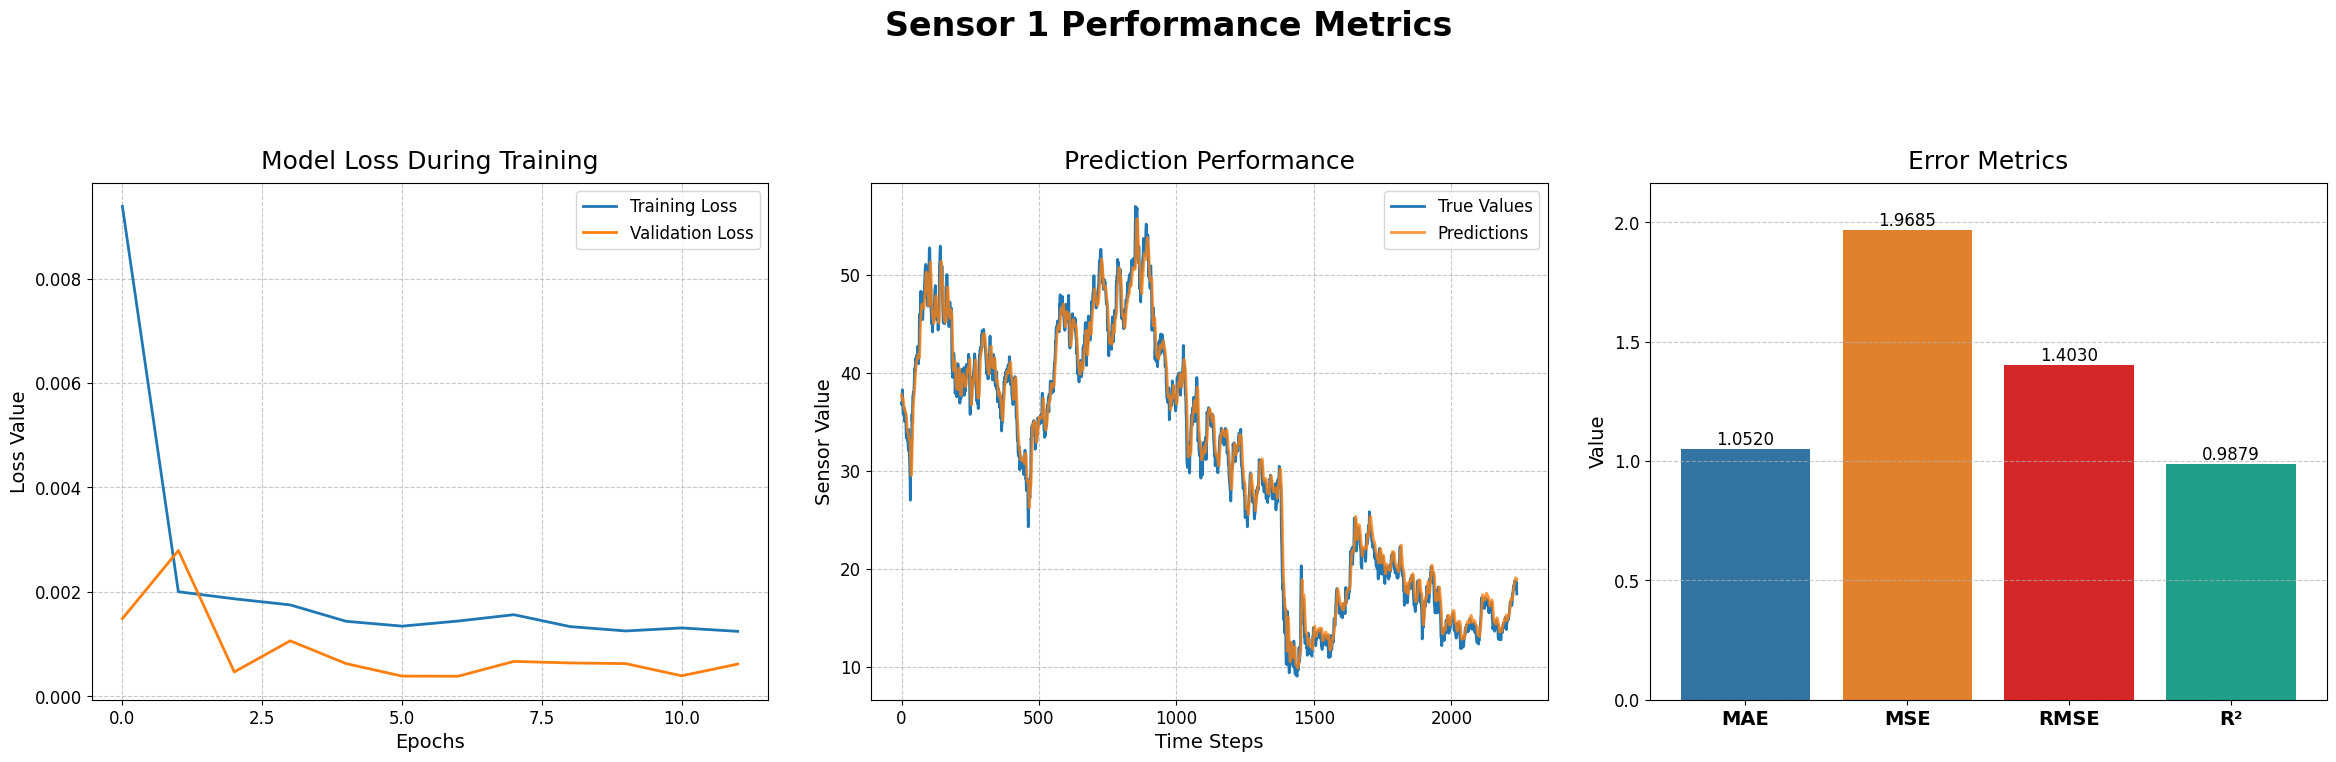


Metrics for Sensor 2:
Mean Absolute Error (MAE): 2.6841
Mean Squared Error (MSE): 26.3213
Root Mean Squared Error (RMSE): 5.1304
R² Score: 0.9904
Plot for Sensor 2 saved as 'sensor_2_results.png'


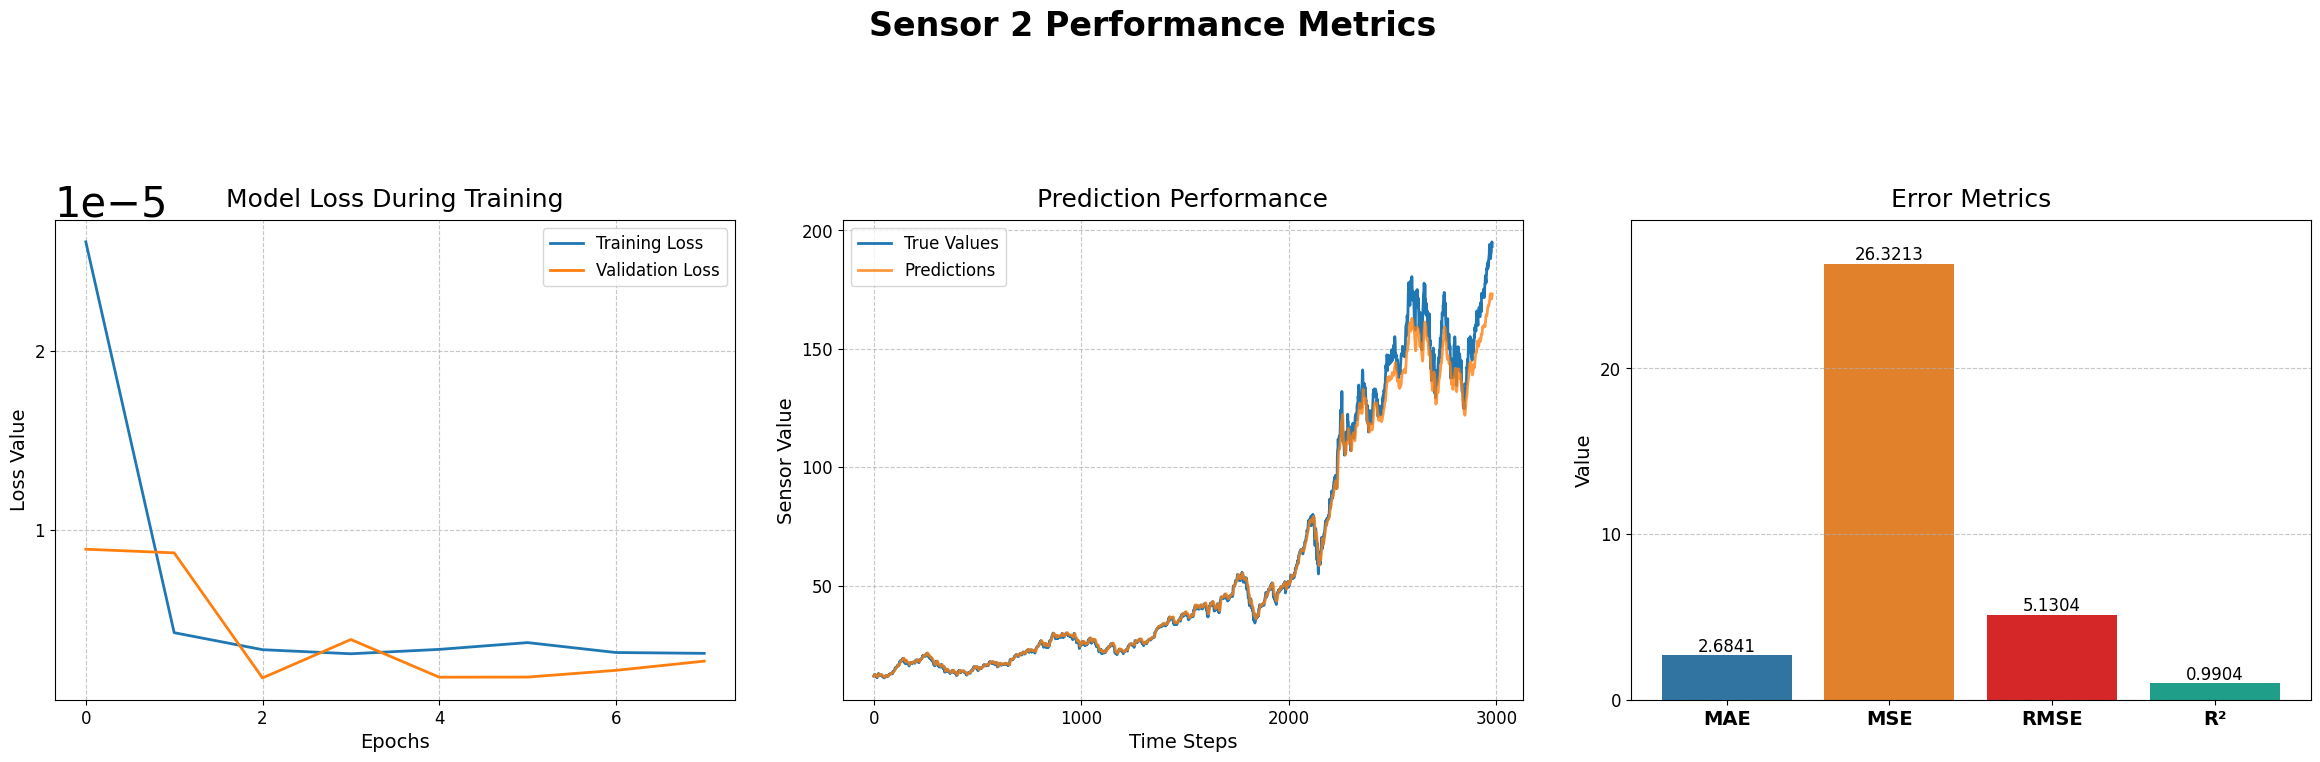


Metrics for Sensor 3:
Mean Absolute Error (MAE): 2.1464
Mean Squared Error (MSE): 9.2498
Root Mean Squared Error (RMSE): 3.0413
R² Score: 0.9910
Plot for Sensor 3 saved as 'sensor_3_results.png'


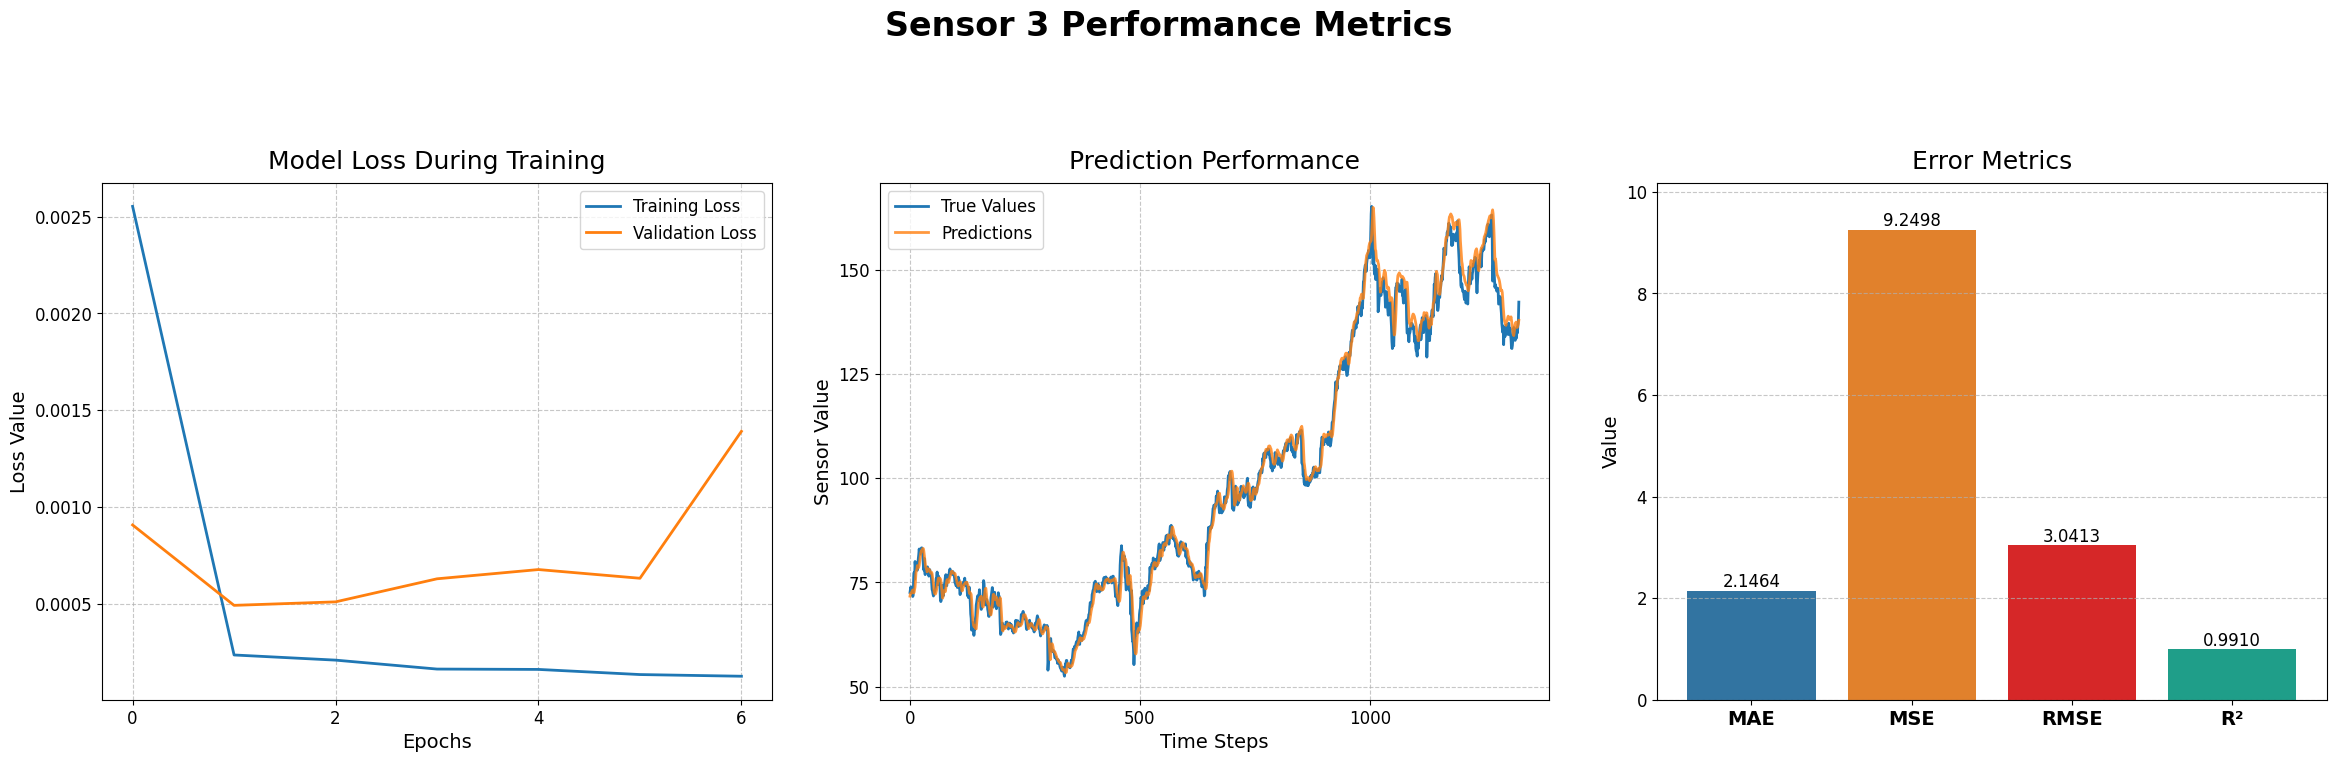


Metrics for Sensor 4:
Mean Absolute Error (MAE): 1.9102
Mean Squared Error (MSE): 8.9920
Root Mean Squared Error (RMSE): 2.9987
R² Score: 0.9927
Plot for Sensor 4 saved as 'sensor_4_results.png'


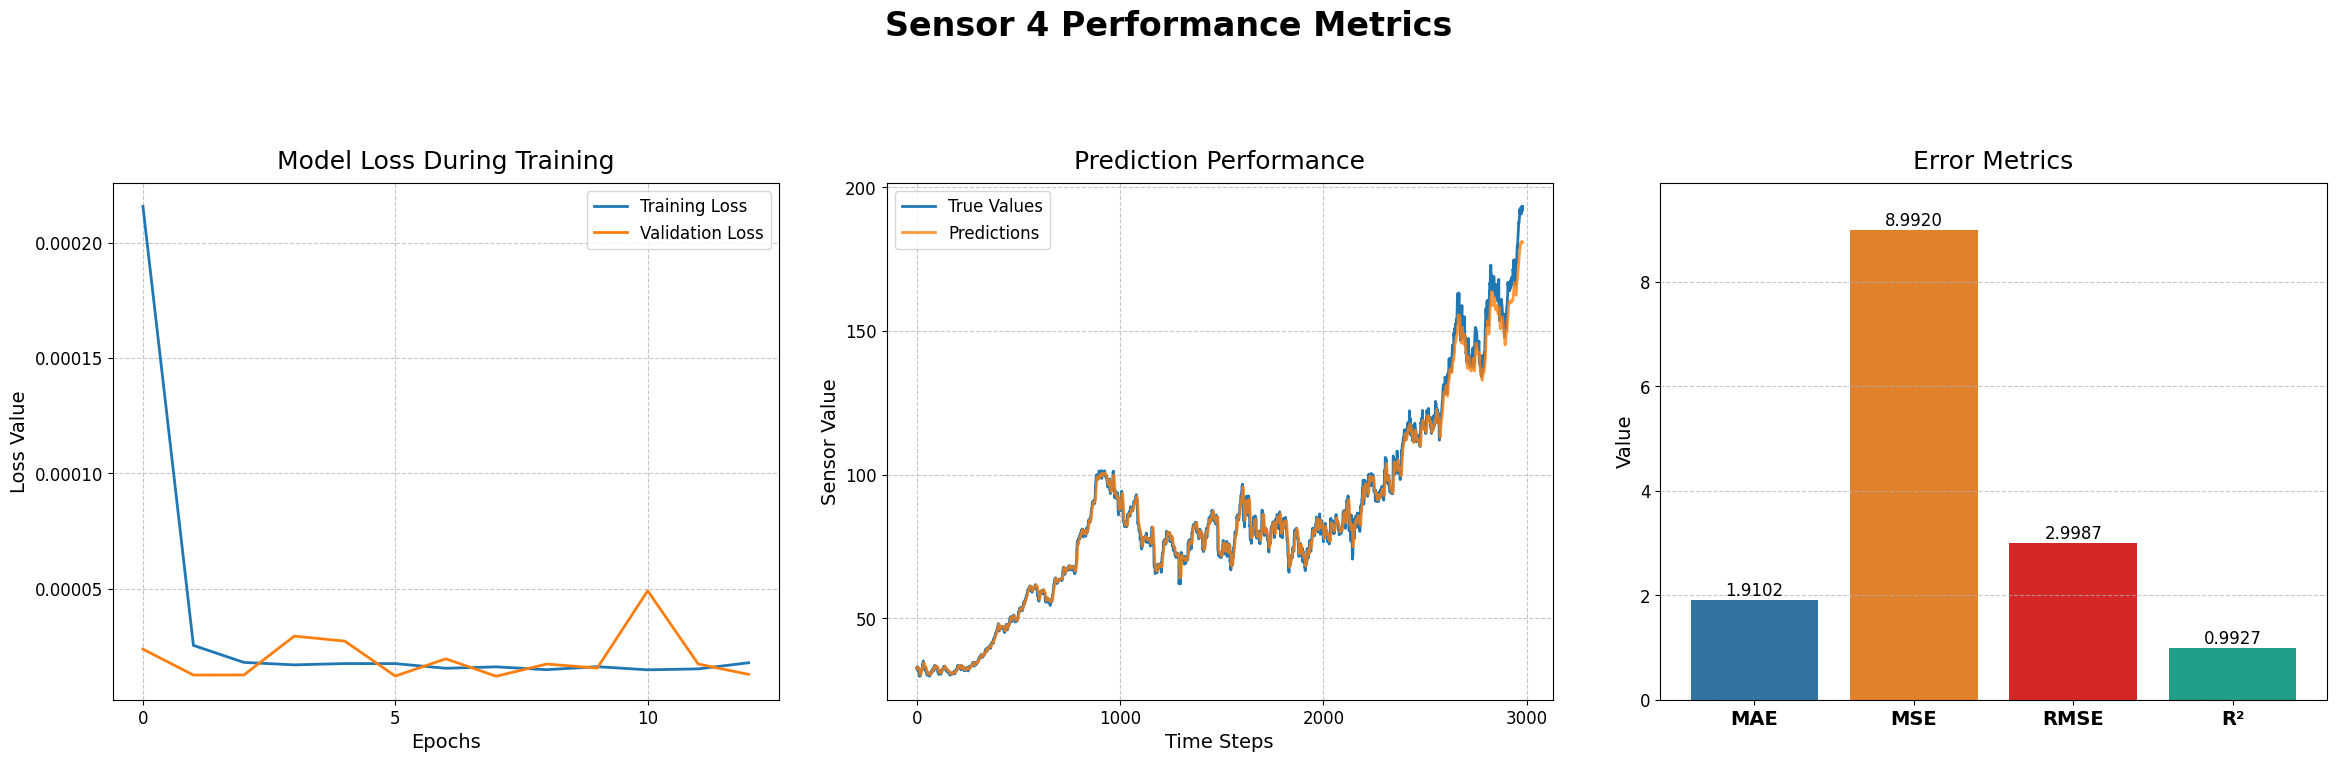


Metrics for Sensor 5:
Mean Absolute Error (MAE): 0.1302
Mean Squared Error (MSE): 0.0277
Root Mean Squared Error (RMSE): 0.1664
R² Score: 0.9775
Plot for Sensor 5 saved as 'sensor_5_results.png'


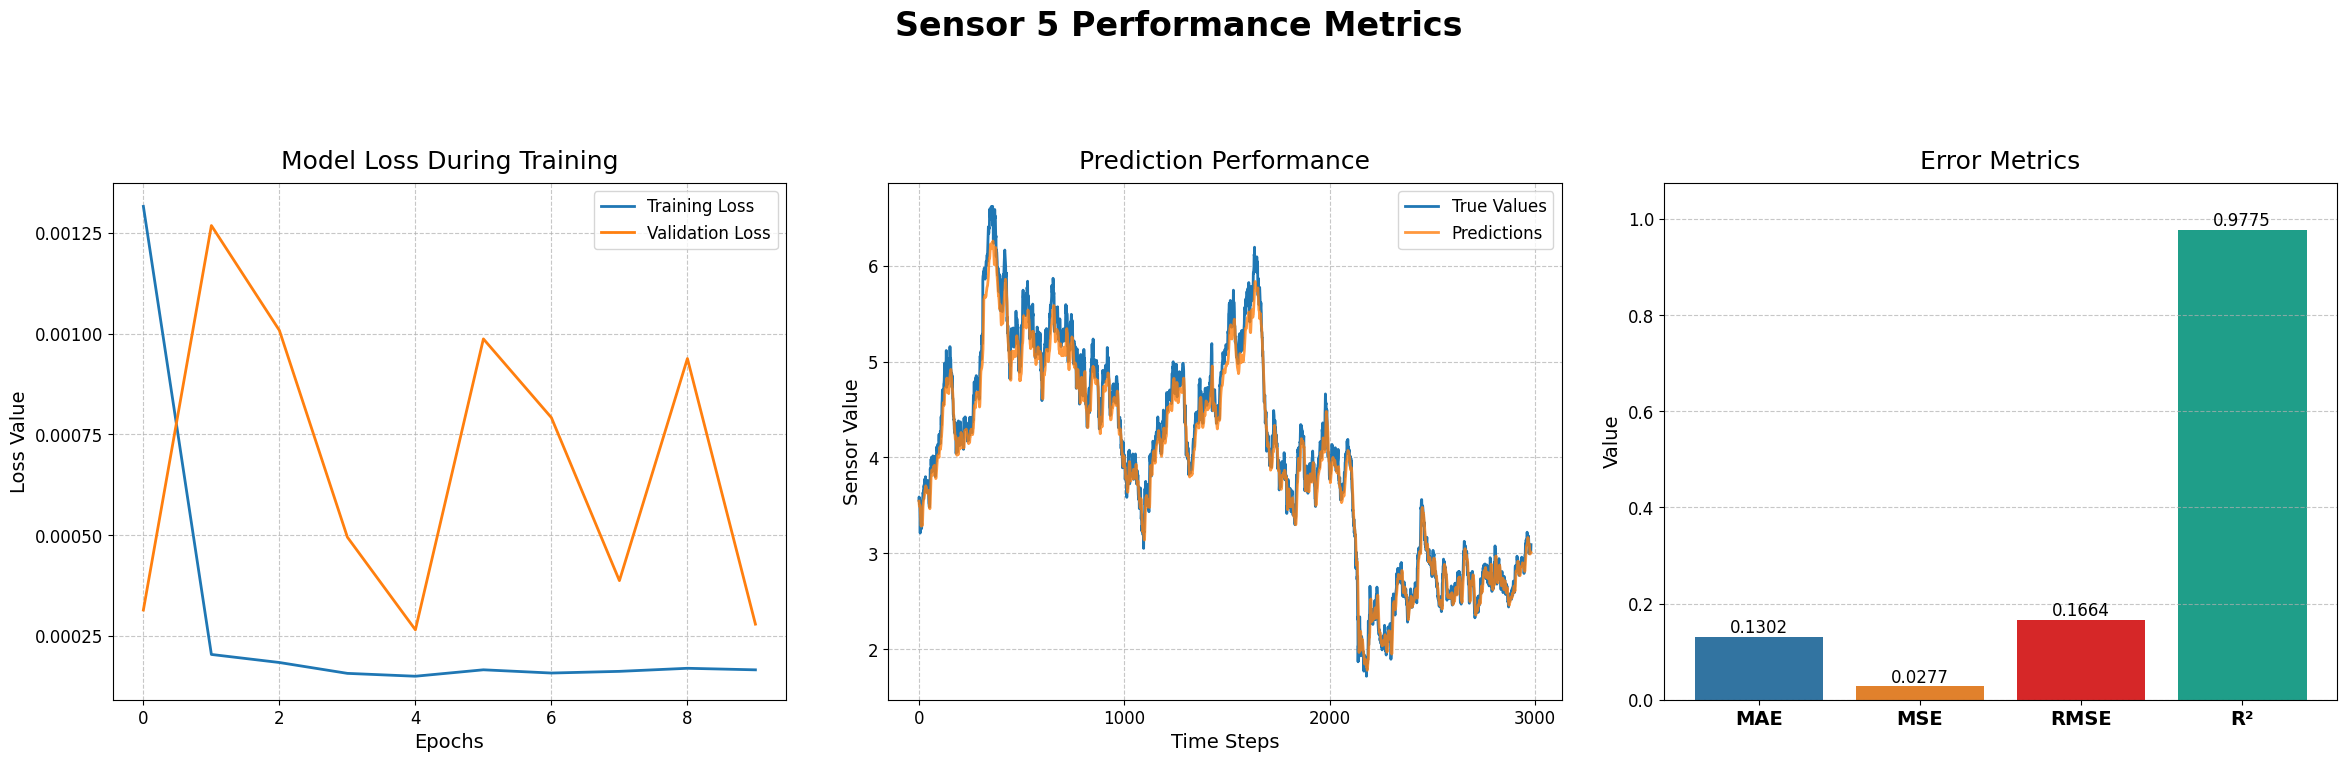


Metrics for Sensor 6:
Mean Absolute Error (MAE): 15.3037
Mean Squared Error (MSE): 287.7474
Root Mean Squared Error (RMSE): 16.9631
R² Score: 0.0717
Plot for Sensor 6 saved as 'sensor_6_results.png'


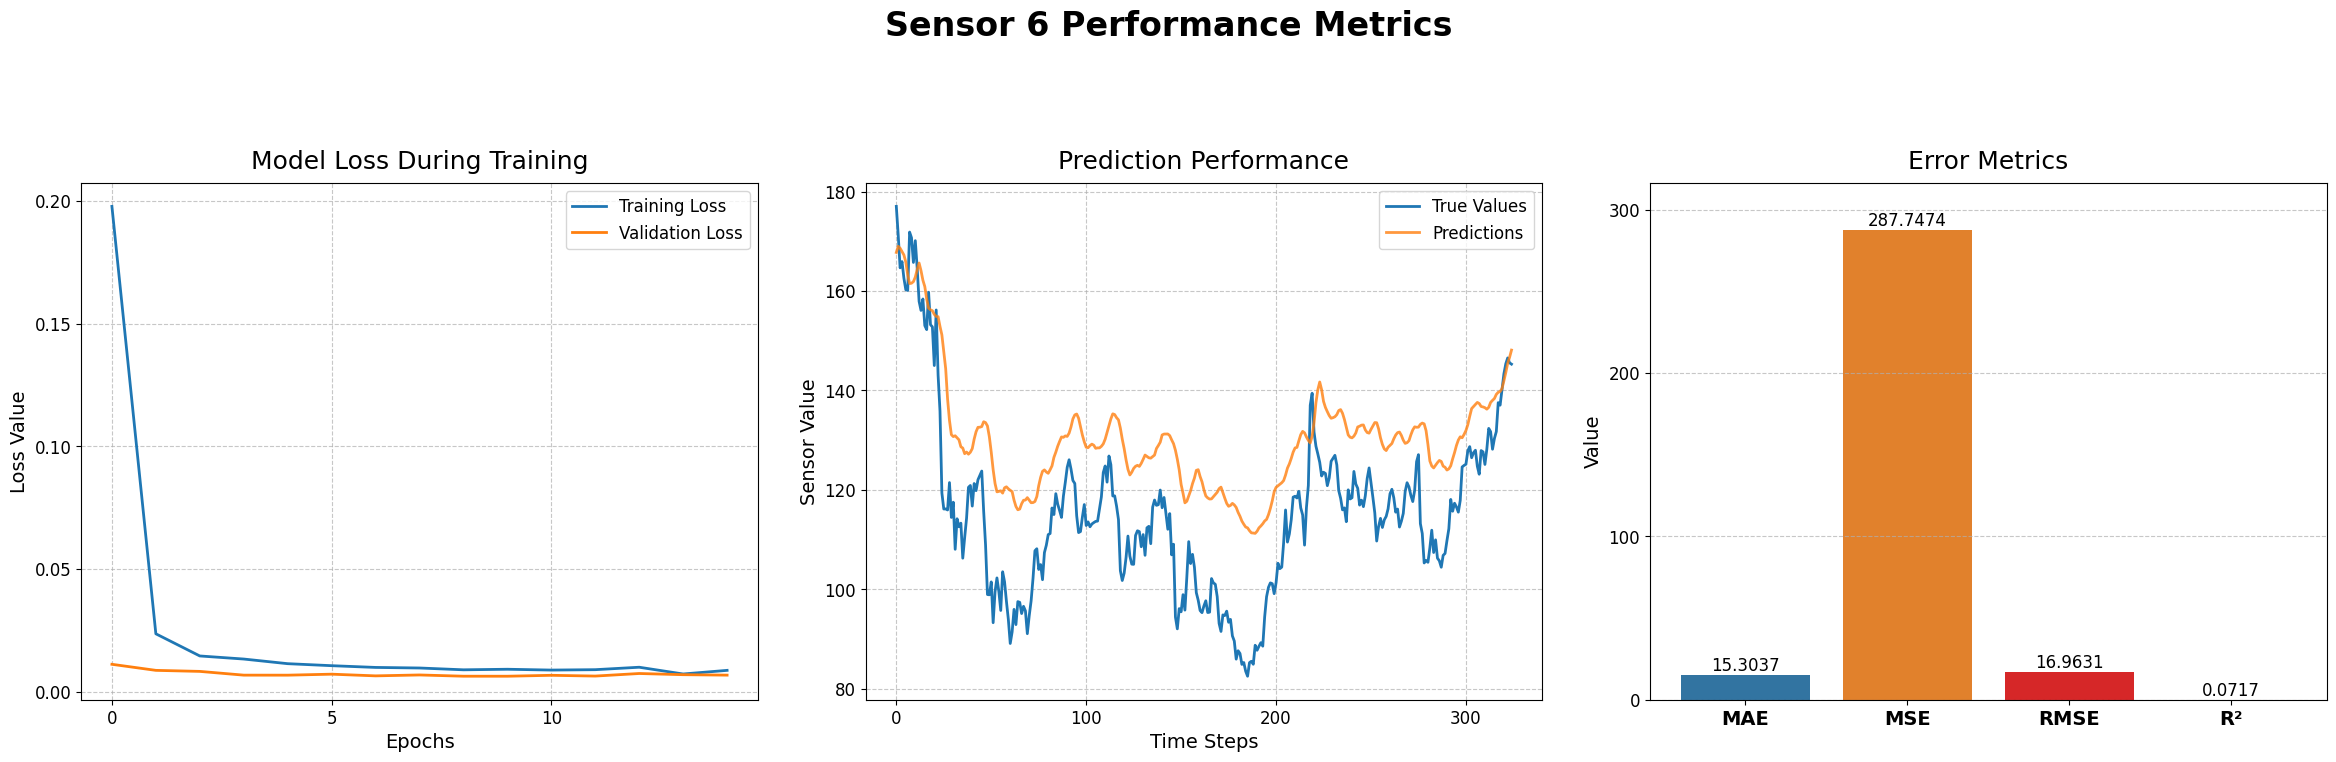


Metrics for Sensor 7:
Mean Absolute Error (MAE): 2.2951
Mean Squared Error (MSE): 13.4748
Root Mean Squared Error (RMSE): 3.6708
R² Score: 0.9877
Plot for Sensor 7 saved as 'sensor_7_results.png'


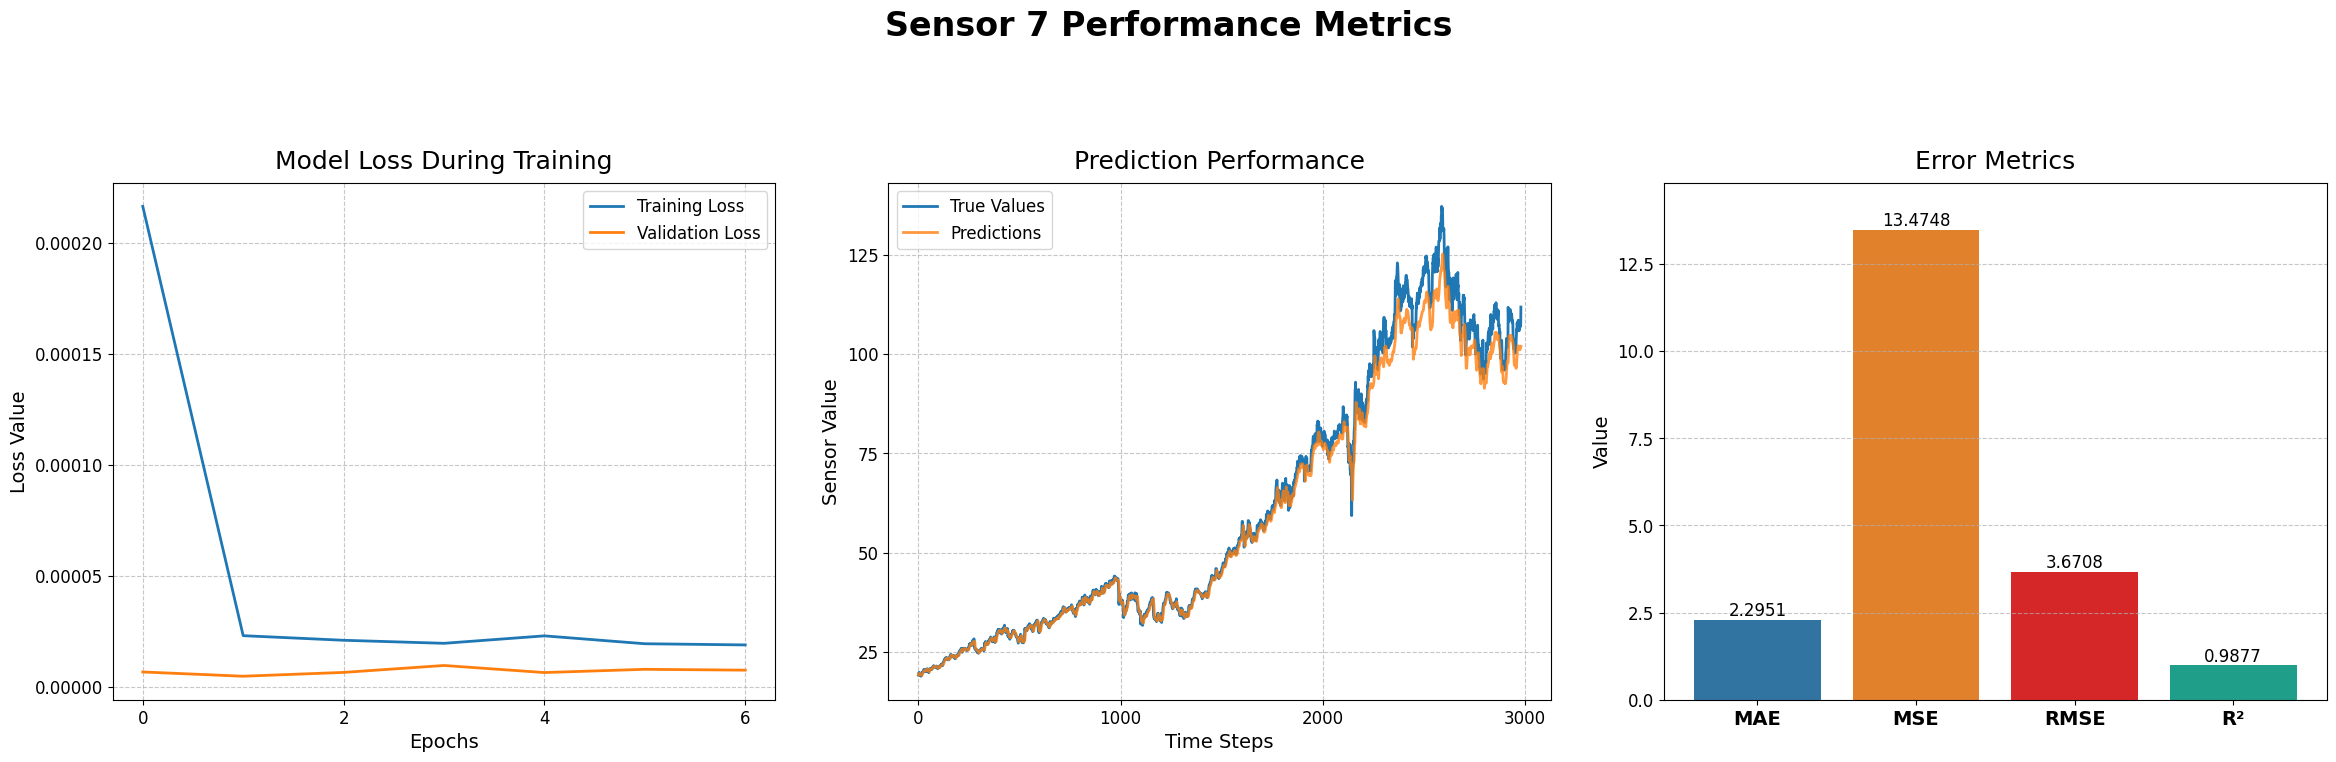


Metrics for Sensor 8:
Mean Absolute Error (MAE): 0.9681
Mean Squared Error (MSE): 2.6642
Root Mean Squared Error (RMSE): 1.6322
R² Score: 0.9857
Plot for Sensor 8 saved as 'sensor_8_results.png'


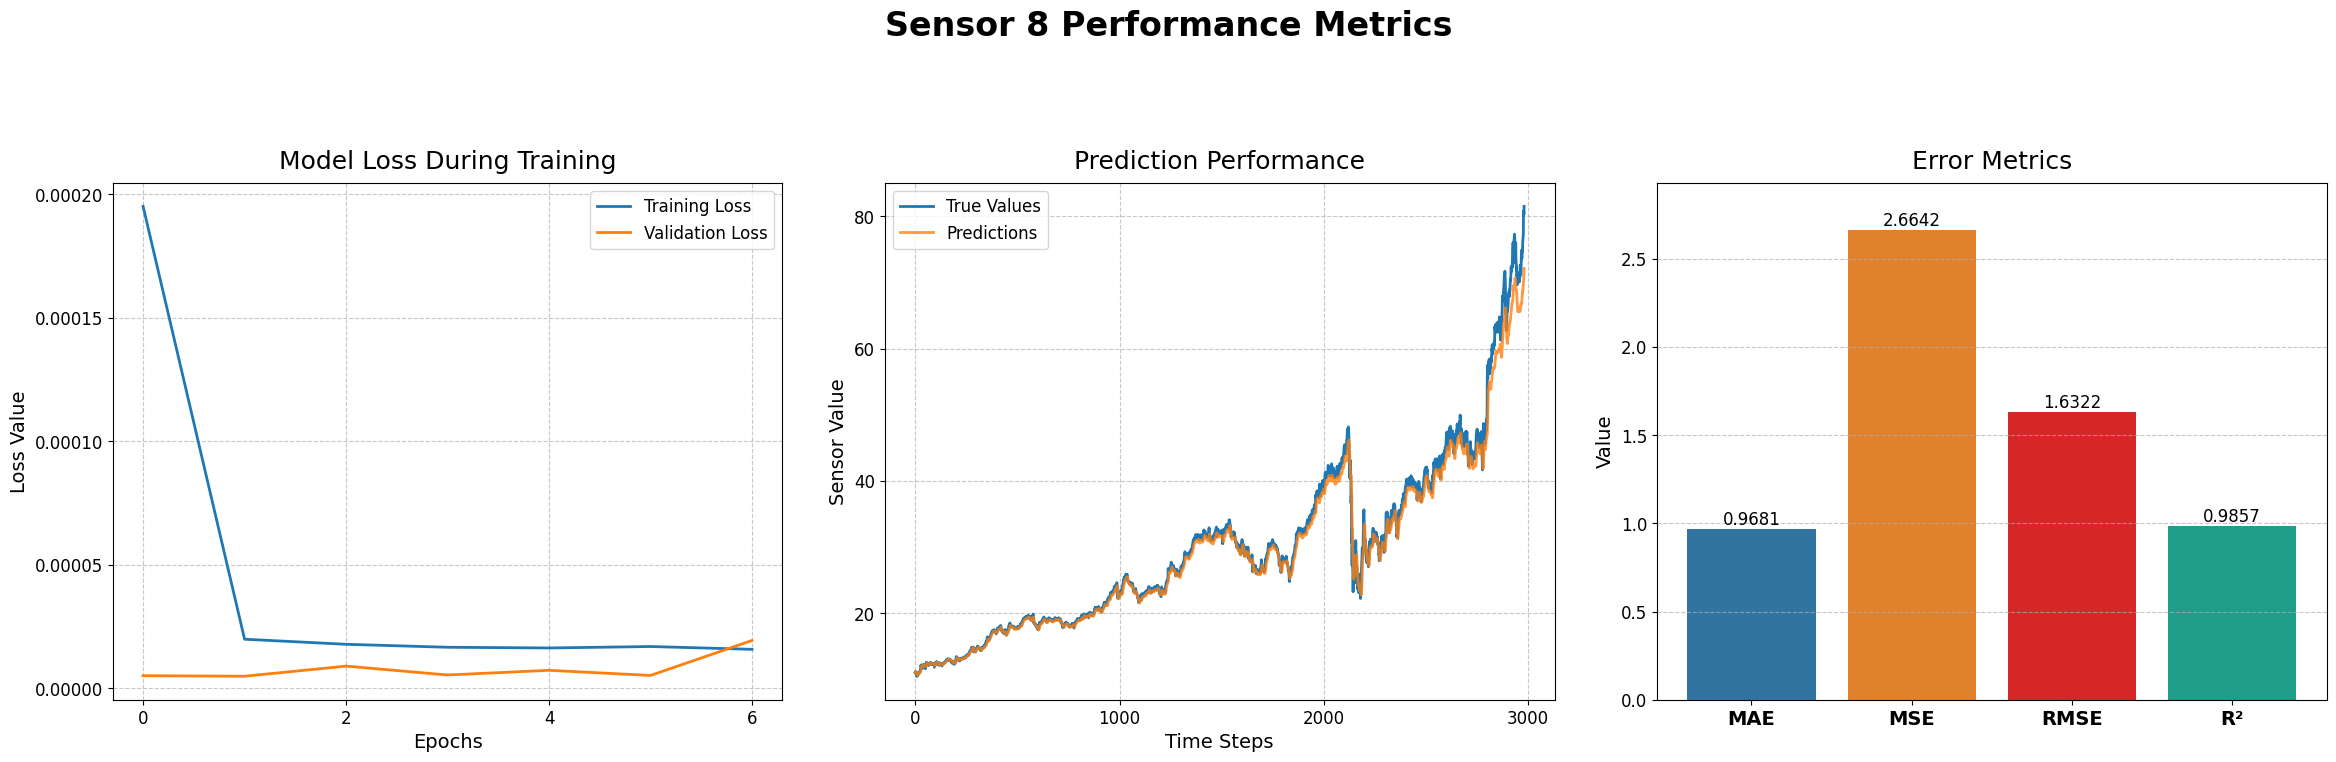


Metrics for Sensor 9:
Mean Absolute Error (MAE): 0.5684
Mean Squared Error (MSE): 0.5226
Root Mean Squared Error (RMSE): 0.7229
R² Score: 0.2961
Plot for Sensor 9 saved as 'sensor_9_results.png'


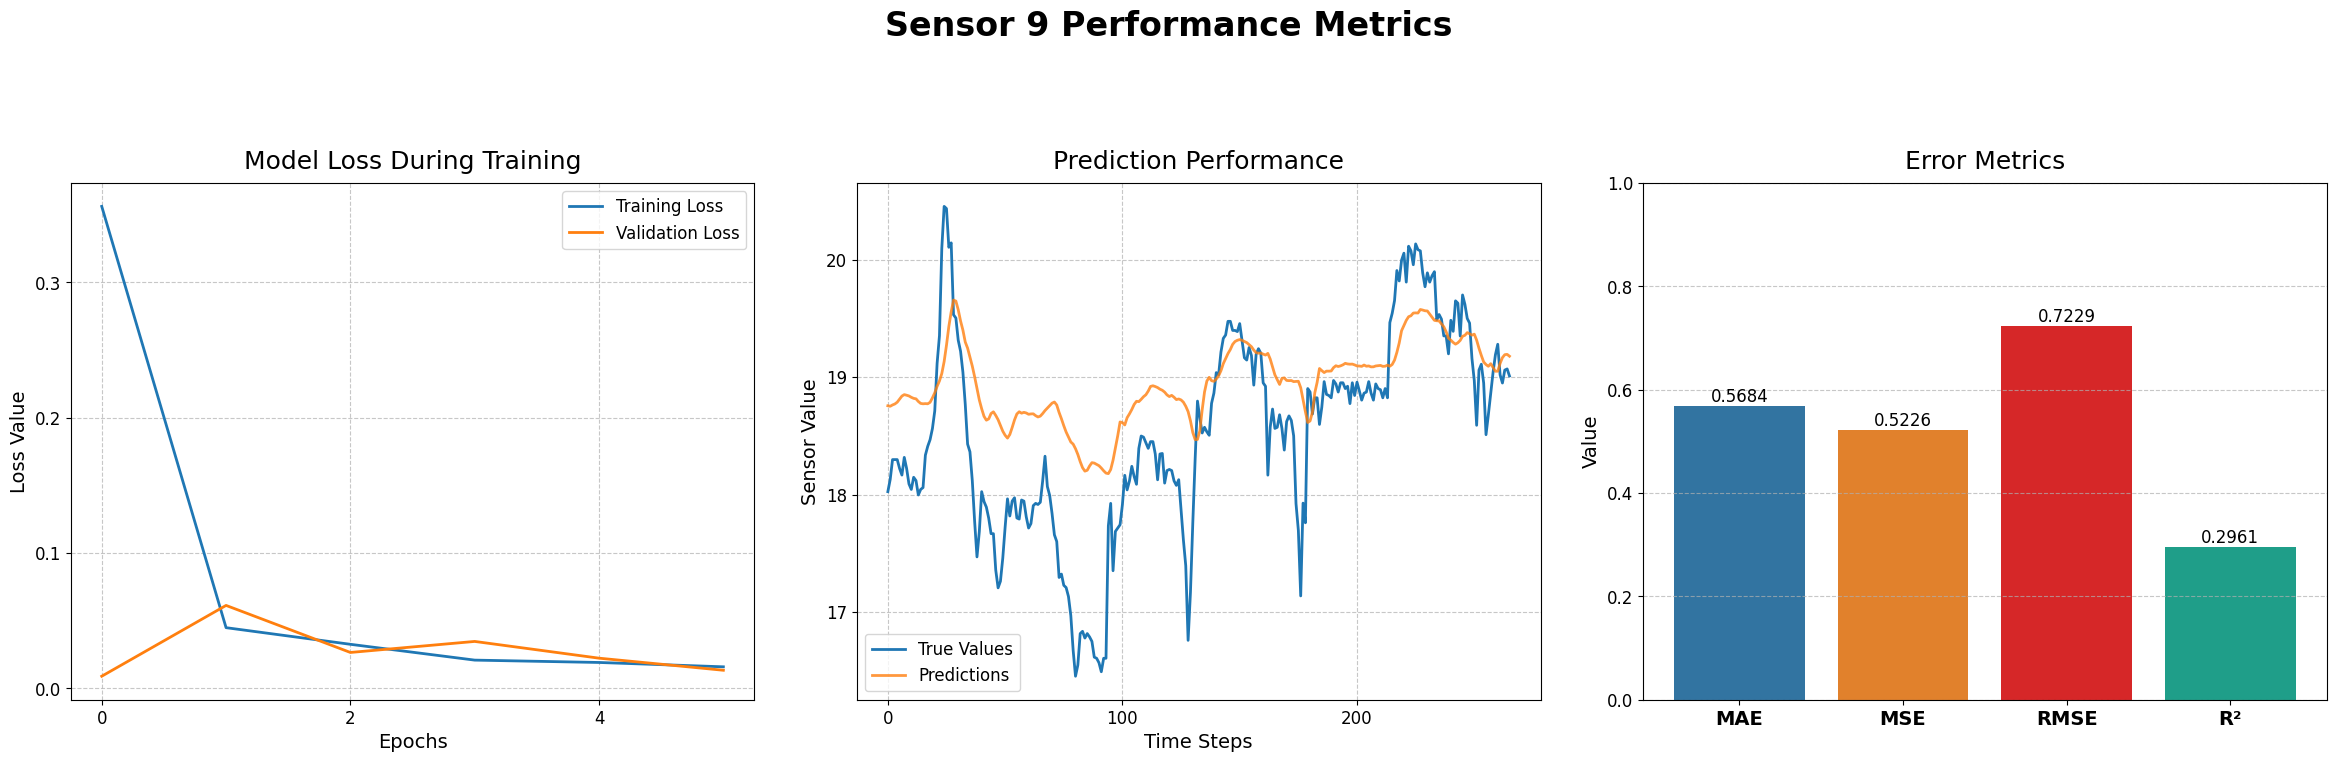

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


for sensor_id in range(len(sensors_ids)):
    if models[sensor_id] is None or histories[sensor_id] is None:
        print(f"Skipping plots for Sensor {sensors_ids[sensor_id]} due to insufficient data")
        continue
        

    history = histories[sensor_id]
    test_predict = test_predictions[sensor_id]
    Y_test_original = Y_test_originals[sensor_id]
    
   
    mae = mean_absolute_error(Y_test_original, test_predict)
    mse = mean_squared_error(Y_test_original, test_predict)
    rmse = np.sqrt(mse) 
    r2 = r2_score(Y_test_original, test_predict)
    
   
    print(f"\nMetrics for Sensor {sensors_ids[sensor_id]}:")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")
        
    
    plt.figure(figsize=(24, 8))
    
    
    plt.suptitle(f'Sensor {sensors_ids[sensor_id]} Performance Metrics', 
                 fontsize=24, fontweight='bold', y=0.98)
        
  
    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title('Model Loss During Training', fontsize=18, pad=10)
    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Loss Value', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
        
   
    plt.subplot(1, 3, 2)
    plt.plot(Y_test_original, label='True Values', linewidth=2)
    plt.plot(test_predict, label='Predictions', linewidth=2, alpha=0.8)
    plt.title('Prediction Performance', fontsize=18, pad=10)
    plt.xlabel('Time Steps', fontsize=14)
    plt.ylabel('Sensor Value', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
  
    plt.subplot(1, 3, 3)
    metrics = ['MAE', 'MSE', 'RMSE', 'R²']
    values = [mae, mse, rmse, r2]
    
  
    bars = plt.bar(metrics, values, color=['#3274A1', '#E1812C', '#D62728', '#1F9E89'])
    
   
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=12, rotation=0)
    
    plt.title('Error Metrics', fontsize=18, pad=10)
    plt.ylabel('Value', fontsize=14)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.xticks(fontsize=14, fontweight='bold')
    plt.yticks(fontsize=12)
    

    plt.ylim([min(min(values)*0.9, 0), max(max(values)*1.1, 1)])
        
    
    plt.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)
        
    plt.savefig(f"sensor_{sensors_ids[sensor_id]}_results.png", dpi=300, bbox_inches='tight')
    print(f"Plot for Sensor {sensors_ids[sensor_id]} saved as 'sensor_{sensors_ids[sensor_id]}_results.png'")
        
    
    plt.show()


In [30]:
def predict_T(p, x_t, predictions):
    target_value = (1 + p) * x_t
    for T, x_pred in enumerate(predictions):
        if x_pred >= target_value:
            return T
    return -1


with open('prediction_results.txt', 'w') as f:
    f.write("Prediction Results for Sensor Increase Times\n")
    f.write("===========================================\n\n")
    
    for i, sensor_id in enumerate(processed_sensors):
        if models[i] is None:
            f.write(f"Sensor {processed_sensors[i]}: No model available\n")
            continue
            
        x_t = Y_test_originals[i][0][0]
        
        predictions = test_predictions[i].flatten()
        
        percentages = [0.1]   #10%, 
        
        f.write(f"Sensor {processed_sensors[i]}:\n")
        f.write(f"  Initial value: {x_t}\n")
        
        for p in percentages:
            T = predict_T(p, x_t, predictions)
            result_text = f"  To increase {p*100:.1f}%, the least T is: {T}"
            print(result_text) 
            f.write(result_text + "\n")
        
        f.write("\n")  

print(f"Results saved to prediction_results.txt")


  To increase 10.0%, the least T is: 23
  To increase 10.0%, the least T is: 53
  To increase 10.0%, the least T is: 89
  To increase 10.0%, the least T is: 21
  To increase 10.0%, the least T is: 309
  To increase 10.0%, the least T is: 73
  To increase 10.0%, the least T is: -1
  To increase 10.0%, the least T is: 73
  To increase 10.0%, the least T is: 47
  To increase 10.0%, the least T is: -1
Results saved to prediction_results.txt
